## Modbus IDS (unsupervised) — cascade pipeline

Logic lives in **`ids_pipeline`** at the repo root: window Isolation Forest + per-message Isolation Forest, optional **time-based train split**, and **cascade** alerts (window anomaly gates packet-level ranking or AND rule).

**Dependencies:** `pandas`, `numpy`, `scikit-learn`, `matplotlib`

**Local run:** open this repo in Cursor/VS Code (or Jupyter), create a venv if you like, `pip install` the packages above, then run all cells. Paths resolve to the repo root automatically. Point **`DATA_DIR`** in the paths cell at your capture folder (e.g. `Full Data 4-20/`) with `modbus_dataset*.csv` and `ids_events_orch*.jsonl`.

If **`train_data/*.csv`** exists (e.g. benign-only capture), the pipeline **fits** Isolation Forests on that file and **scores** the eval CSV under **`Full Data 4-20/`** (or whatever `DATA_DIR` is) for metrics vs JSONL. If `train_data/` is empty, it falls back to a single mixed capture with `fit_benign_only` + JSONL masking.


In [1]:
%pip install -q pandas numpy scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _find_repo_root(start: Path) -> Path:
    """Repo root: first ancestor that contains ``ids_pipeline/cascade.py``."""
    for p in [start, *start.parents]:
        if (p / "ids_pipeline" / "cascade.py").is_file():
            return p
    here = start.resolve()
    return here.parent if here.name == "notebooks" else here


ROOT = _find_repo_root(Path.cwd().resolve())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Drop stale imports so notebook picks up edits to ids_pipeline without restarting kernel
for _k in list(sys.modules):
    if _k == "ids_pipeline" or _k.startswith("ids_pipeline."):
        del sys.modules[_k]

from ids_pipeline import (
    CascadeConfig,
    fit_and_score,
    fit_train_score_eval,
    first_orchestrator_start_epoch,
    load_attack_intervals,
    load_clean_csv,
    packet_attack_labels,
    resolve_label_ts_offset,
    suggest_eval_ts_offset_sec,
    time_alignment_report,
    window_attack_overlap_labels,
)

### Paths and configuration

- **`TRAIN_FRAC`**: `None` = fit on the full capture; otherwise a value in `(0,1)` fits scalers + both forests only on rows with `ts < t_cut` and windows with `t_end <= t_cut`, then scores **all** rows. Report **test-only** metrics in a later cell when split is on.
- **`cascade_mode`**: `"top_k"` — within each window flagged by the window IF, mark the **`cascade_top_k`** lowest `pkt_if_score` messages; `"and"` — require packet IF outlier too.
- **`EVAL_TS_OFFSET_SEC`**: `None` = auto offset (computed before training); or set a float. Used for labels, benign-only fit, and evaluation.
- **`fit_benign_only`**: when `True`, Isolation Forests are fit only on traffic **outside** JSONL attack windows (after offset), so attacks are not absorbed into the “normal” cloud.
- **`pkt_contamination` / `cascade_top_k`**: raise contamination or top-k for more alerts (recall); lower for fewer false positives (precision).
- **`train_data/`**: optional **benign-only** CSV(s); first `*.csv` alphabetically is used to **fit**; evaluation uses **`DATA_DIR`** (e.g. `Full Data 4-20/`) mixed capture + JSONL.

In [3]:
DATA_DIR = ROOT / "Full Data 4-20"
_eval_csvs = sorted(DATA_DIR.glob("modbus_dataset*.csv")) if DATA_DIR.is_dir() else []
CSV_PATH = _eval_csvs[0] if _eval_csvs else (DATA_DIR / "modbus_dataset_2026-04-20 12_50_07.581729.csv")
JSONL_PATHS = [
    DATA_DIR / "ids_events_orch1.jsonl",
    DATA_DIR / "ids_events_orch2.jsonl",
    DATA_DIR / "ids_events_orch3.jsonl",
]

# Benign-only capture (e.g. 2h) for fitting; set to None to skip and use single-file mode below
TRAIN_DATA_DIR = ROOT / "train_data"
_train_csvs = sorted(TRAIN_DATA_DIR.glob("*.csv")) if TRAIN_DATA_DIR.is_dir() else []
TRAIN_CSV = _train_csvs[0] if _train_csvs else None

# ``None`` = auto grid-search offset so eval packet times overlap JSONL episode intervals
EVAL_TS_OFFSET_SEC = None  # or set a float (seconds added to eval CSV ``ts`` for labels)

EVAL_CSV = CSV_PATH
df_eval = load_clean_csv(EVAL_CSV)
EVAL_TS_OFFSET_SEC, attack_intervals = resolve_label_ts_offset(
    df_eval["ts"].values, JSONL_PATHS, EVAL_TS_OFFSET_SEC
)
print(
    f"Label offset: EVAL_TS_OFFSET_SEC={EVAL_TS_OFFSET_SEC}  (intervals: {len(attack_intervals)})"
)
print(time_alignment_report(df_eval["ts"].values, attack_intervals, offset_sec=EVAL_TS_OFFSET_SEC))

cfg = CascadeConfig(
    window_sec=10.0,
    include_dst_context=True,
    drop_src_identity=True,
    win_contamination="auto",
    pkt_contamination=0.03,
    n_estimators_win=300,
    n_estimators_pkt=150,
    packet_include_dst=False,
    train_frac=None,
    fit_benign_only=False,
    cascade_mode="top_k",
    cascade_top_k=40,
)

if TRAIN_CSV is not None:
    df_train = load_clean_csv(TRAIN_CSV)
    print(f"Fit IF on benign train: {TRAIN_CSV.name} ({len(df_train)} rows)")
    print(f"Score / evaluate on: {EVAL_CSV.name} ({len(df_eval)} rows)")
    res = fit_train_score_eval(
        df_train,
        df_eval,
        cfg,
        attack_intervals=None,
        label_ts_offset_sec=0.0,
    )
else:
    print("No CSV in train_data/ — fit and score on EVAL_CSV only (fit_benign_only uses JSONL).")
    cfg_mixed = CascadeConfig(
        window_sec=cfg.window_sec,
        include_dst_context=cfg.include_dst_context,
        drop_src_identity=cfg.drop_src_identity,
        win_contamination=cfg.win_contamination,
        pkt_contamination=cfg.pkt_contamination,
        n_estimators_win=cfg.n_estimators_win,
        n_estimators_pkt=cfg.n_estimators_pkt,
        packet_include_dst=cfg.packet_include_dst,
        train_frac=0.7,
        fit_benign_only=True,
        cascade_mode=cfg.cascade_mode,
        cascade_top_k=cfg.cascade_top_k,
    )
    res = fit_and_score(
        df_eval,
        cfg_mixed,
        attack_intervals=attack_intervals,
        label_ts_offset_sec=float(EVAL_TS_OFFSET_SEC),
    )

df, feat, pkt = res.df, res.feat, res.pkt
print("t_cut:", res.t_cut, "| separate_eval_corpus:", getattr(res, "separate_eval_corpus", False))
df.head()


Label offset: EVAL_TS_OFFSET_SEC=14160.0  (intervals: 68)
Time alignment (epoch seconds)
  CSV packets: n=479500 min=1776681948.036 max=1776689199.342
  JSONL episode union: n_intervals=68 min=1776696521.354 max=1776703717.205
  Packets inside any interval (ts + 14160): 35293 (7.360%)
Fit IF on benign train: modbus_dataset_2026-04-19 22_41_42.288893.csv (421704 rows)
Score / evaluate on: modbus_dataset_2026-04-20 12_50_07.581729.csv (479500 rows)
t_cut: None | separate_eval_corpus: True


,Time,Dst IP,Trans_ID,Unit_ID,Func,Type,Data,ts,w
0,2026-04-20 10:45:48.036,10.30.0.5,1,0,3.0,Request,"startAddr: 0, quantity: 4",1.776682e+09,0
1,2026-04-20 10:45:48.037,10.30.0.22,1,0,3.0,Response,"byteCount: 8, registerVal: [141, 334, 281, 349]",1.776682e+09,0
2,2026-04-20 10:45:48.037,10.30.0.5,2,0,4.0,Request,"startAddr: 2, quantity: 5",1.776682e+09,0
3,2026-04-20 10:45:48.038,10.30.0.22,2,0,4.0,Response,"byteCount: 10, registerVal: [0, 0, 0, 340, 4500]",1.776682e+09,0
4,2026-04-20 10:45:49.857,10.30.0.5,1,0,2.0,Request,"startAddr: 0, quantity: 6",1.776682e+09,0


### Quick counts

In [4]:
n_win = len(feat)
n_win_anom = int((feat["if_pred"] == -1).sum())
n_pkt = len(pkt)
n_pkt_anom = int((pkt["pkt_if_pred"] == -1).sum())
n_cascade = int(pkt["cascade_alert"].sum())
print(f"Windows: {n_win} | window IF anomalies: {n_win_anom}")
print(f"Messages: {n_pkt} | packet IF anomalies: {n_pkt_anom}")
print(f"Cascade alerts (mode={cfg.cascade_mode}): {n_cascade}")

Windows: 726 | window IF anomalies: 236
Messages: 479500 | packet IF anomalies: 26382
Cascade alerts (mode=top_k): 9440


### Window IF score vs time

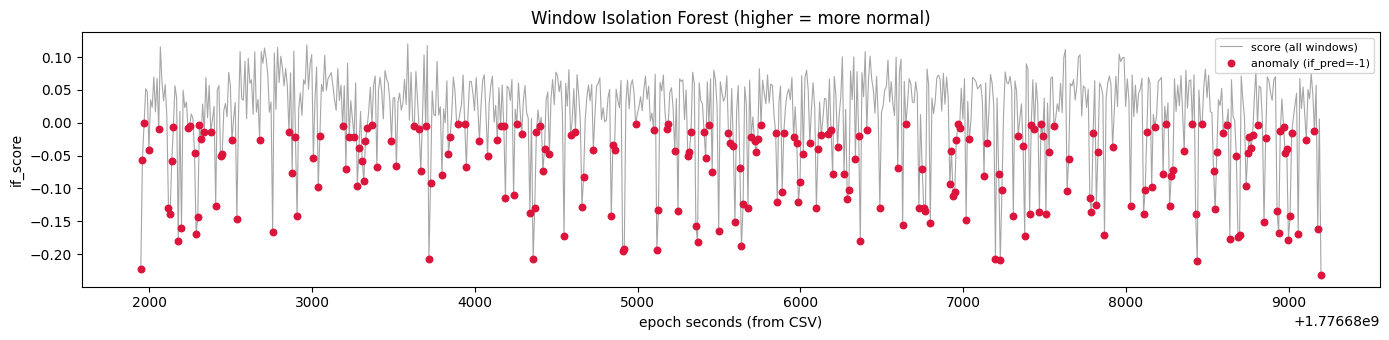

In [5]:
fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(feat["t_start"], feat["if_score"], lw=0.8, color="0.65", label="score (all windows)")
anomaly_mask = feat["if_pred"] == -1
if anomaly_mask.any():
    ax.scatter(
        feat.loc[anomaly_mask, "t_start"],
        feat.loc[anomaly_mask, "if_score"],
        color="crimson",
        s=22,
        zorder=5,
        label="anomaly (if_pred=-1)",
    )
if res.t_cut is not None and not getattr(res, "separate_eval_corpus", False):
    ax.axvline(res.t_cut, color="navy", ls="--", lw=1, label="train | test cut")
ax.set_title("Window Isolation Forest (higher = more normal)")
ax.set_xlabel("epoch seconds (from CSV)")
ax.set_ylabel("if_score")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

### Per-message score histogram

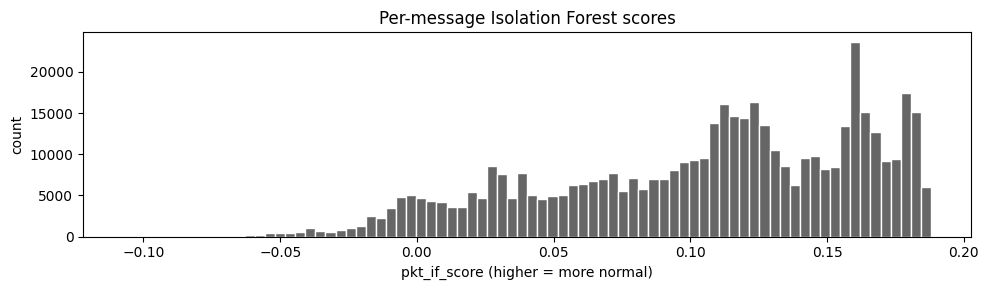

In [6]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(pkt["pkt_if_score"], bins=80, color="0.4", edgecolor="white")
ax.set_xlabel("pkt_if_score (higher = more normal)")
ax.set_ylabel("count")
ax.set_title("Per-message Isolation Forest scores")
plt.tight_layout()
plt.show()

### Most anomalous messages (global)

In [7]:
show_pkt = ["Time", "Dst IP", "Func", "Type", "Unit_ID", "Trans_ID", "iat_sec", "data_len", "pkt_if_score", "pkt_if_pred", "win_if_pred", "cascade_alert"]
show_pkt = [c for c in show_pkt if c in pkt.columns]
worst = pkt.sort_values("pkt_if_score", ascending=True).head(40)
print(worst[show_pkt].to_string())

                          Time     Dst IP  Func     Type  Unit_ID  Trans_ID  iat_sec  data_len  pkt_if_score  pkt_if_pred  win_if_pred  cascade_alert
244694 2026-04-20 11:48:02.545  10.30.0.5   3.0  Request        0         1    0.267        28     -0.107301           -1           -1           True
27030  2026-04-20 10:52:21.286  10.30.0.5   3.0  Request        0       153    0.372        25     -0.106000           -1           -1           True
90410  2026-04-20 11:08:49.818  10.30.0.3   3.0  Request        0       549    0.344        25     -0.099948           -1           -1           True
90446  2026-04-20 11:08:50.464  10.30.0.5   3.0  Request        0       553    0.339        25     -0.099948           -1           -1           True
28952  2026-04-20 10:52:53.768  10.30.0.3   3.0  Request        0       167    0.282        25     -0.099208           -1            1          False
381080 2026-04-20 12:22:45.831  10.30.0.5   3.0  Request        0      2319    0.334        25     -

### Evaluation vs JSONL (episode intervals)

Ground truth: packet timestamp inside any **`episode_start`–`episode_end`** interval. Compare **packet IF only** vs **cascade** flags. When `train_frac` is set, metrics are shown on **all** data and on **test** rows (`ts >= t_cut`) separately.

The **paths** cell resolves **`EVAL_TS_OFFSET_SEC`** when it is `None` (grid search). The evaluation cell prints alignment again and re-applies suggest only if the offset was never set (e.g. you ran evaluation alone).

In [8]:
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
)

attack_intervals = load_attack_intervals(JSONL_PATHS)
print(f"Loaded {len(attack_intervals)} attack intervals")
print(time_alignment_report(pkt["ts"].values, attack_intervals, offset_sec=0.0))
fo = first_orchestrator_start_epoch(JSONL_PATHS)
if fo is not None:
    d0 = fo - float(pkt["ts"].min())
    print(
        "Hint: first orchestrator_start minus CSV ts min = "
        f"{d0:.1f} s (JSONL UTC vs naive CSV clock; auto search refines this)."
    )
if EVAL_TS_OFFSET_SEC is None:
    off, nh = suggest_eval_ts_offset_sec(pkt["ts"].values, attack_intervals)
    EVAL_TS_OFFSET_SEC = float(off)
    print(
        f"AUTO EVAL_TS_OFFSET_SEC = {EVAL_TS_OFFSET_SEC} "
        f"(packets in any interval after shift: {nh})"
    )
else:
    print(f"Using manual EVAL_TS_OFFSET_SEC = {EVAL_TS_OFFSET_SEC}")
print(
    time_alignment_report(
        pkt["ts"].values, attack_intervals, offset_sec=float(EVAL_TS_OFFSET_SEC)
    )
)


def eval_packet(name, y_true, y_pred, score_anom):
    y_true = np.asarray(y_true, dtype=np.int8)
    y_pred = np.asarray(y_pred, dtype=np.int8)
    print(f"\n=== {name} ===")
    print(f"positives (in interval): {int(y_true.sum())} / {len(y_true)} ({100 * y_true.mean():.3f}%)")
    print(f"predicted alerts:         {int(y_pred.sum())} / {len(y_pred)} ({100 * y_pred.mean():.3f}%)")
    print("confusion [true x pred]:", confusion_matrix(y_true, y_pred, labels=[0, 1]).tolist())
    print(
        classification_report(
            y_true,
            y_pred,
            labels=[0, 1],
            target_names=["not_in_interval", "in_attack_interval"],
            digits=3,
            zero_division=0,
        )
    )
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", pos_label=1, zero_division=0
    )
    print(f"Binary P/R/F1 (alert=1): P={p:.4f} R={r:.4f} F1={f1:.4f}")
    if y_true.min() < y_true.max():
        try:
            print(f"ROC-AUC: {roc_auc_score(y_true, score_anom):.4f}")
            print(f"Average precision: {average_precision_score(y_true, score_anom):.4f}")
        except ValueError as e:
            print("ROC/AP:", e)


if not attack_intervals:
    print("No intervals — check JSONL paths.")
else:
    ts_eval = pkt["ts"].values.astype(np.float64) + float(EVAL_TS_OFFSET_SEC)
    y_true = packet_attack_labels(ts_eval, attack_intervals, offset_sec=0.0)
    score_anom = -pkt["pkt_if_score"].values.astype(np.float64)
    y_pkt = (pkt["pkt_if_pred"].values == -1).astype(np.int8)
    y_cas = pkt["cascade_alert"].values.astype(np.int8)

    eval_packet("Packet IF only (all rows)", y_true, y_pkt, score_anom)
    eval_packet("Cascade alerts (all rows)", y_true, y_cas, score_anom)

    if res.t_cut is not None and not getattr(res, "separate_eval_corpus", False):
        m = pkt["ts"].values >= res.t_cut
        eval_packet("Packet IF (test rows only)", y_true[m], y_pkt[m], score_anom[m])
        eval_packet("Cascade (test rows only)", y_true[m], y_cas[m], score_anom[m])

    off = float(EVAL_TS_OFFSET_SEC)
    yw_true = window_attack_overlap_labels(feat, attack_intervals, offset_sec=off)
    yw_pred = (feat["if_pred"].values == -1).astype(np.int8)
    print("\n=== Window IF vs interval overlap ===")
    print(confusion_matrix(yw_true, yw_pred, labels=[0, 1]))
    print(
        classification_report(
            yw_true,
            yw_pred,
            labels=[0, 1],
            target_names=["win_ok", "win_attack_overlap"],
            digits=3,
            zero_division=0,
        )
    )

Loaded 68 attack intervals
Time alignment (epoch seconds)
  CSV packets: n=479500 min=1776681948.036 max=1776689199.342
  JSONL episode union: n_intervals=68 min=1776696521.354 max=1776703717.205
  Packets inside any interval (ts + 0): 0 (0.000%)
Hint: first orchestrator_start minus CSV ts min = 14415.0 s (JSONL UTC vs naive CSV clock; auto search refines this).
Using manual EVAL_TS_OFFSET_SEC = 14160.0
Time alignment (epoch seconds)
  CSV packets: n=479500 min=1776681948.036 max=1776689199.342
  JSONL episode union: n_intervals=68 min=1776696521.354 max=1776703717.205
  Packets inside any interval (ts + 14160): 35293 (7.360%)

=== Packet IF only (all rows) ===
positives (in interval): 35293 / 479500 (7.360%)
predicted alerts:         26382 / 479500 (5.502%)
confusion [true x pred]: [[420697, 23510], [32421, 2872]]
                    precision    recall  f1-score   support

   not_in_interval      0.928     0.947     0.938    444207
in_attack_interval      0.109     0.081     0.093   